In [3]:
import sys, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# notebook is in notebooks/ so go up one level to project root
ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))

OUT_STATS = ROOT / "outputs" / "stats"
OUT_FIGS  = ROOT / "outputs" / "figures"

print(f"ROOT: {ROOT}")
print(f"Stats path exists: {OUT_STATS.exists()}")
print(f"CSV exists: {(OUT_STATS / 'all_training_stats.csv').exists()}")

ROOT: D:\project\ns-research
Stats path exists: True
CSV exists: True


In [4]:
df = pd.read_csv(OUT_STATS / "all_training_stats.csv")
df[['name', 'n_params', 'pesq_mean', 'stoi_mean', 'snr_mean']]

,name,n_params,pesq_mean,stoi_mean,snr_mean
0,rnnoise_baseline,134019,1.8065,0.8291,3.6897
1,dtln_baseline,1202019,1.8606,0.8355,3.7485
2,dtln_alaw,1202019,1.7344,0.8110,3.2210
3,dtln_bcsu,478179,1.8848,0.8353,3.7495
4,dtln_proposed_mask,478179,1.7340,0.8068,3.1091
5,dtln_proposed,494144,1.9135,0.8888,5.0083


In [5]:
histories = {}
for name in df['name']:
    path = OUT_STATS / f"{name}_history.json"
    if path.exists():
        with open(path) as f:
            histories[name] = json.load(f)

print(f"Loaded {len(histories)} history files:")
for name, hist in histories.items():
    print(f"  {name}: {len(hist['train_loss'])} epochs")

Loaded 6 history files:
  rnnoise_baseline: 98 epochs
  dtln_baseline: 111 epochs
  dtln_alaw: 149 epochs
  dtln_bcsu: 112 epochs
  dtln_proposed_mask: 105 epochs
  dtln_proposed: 103 epochs


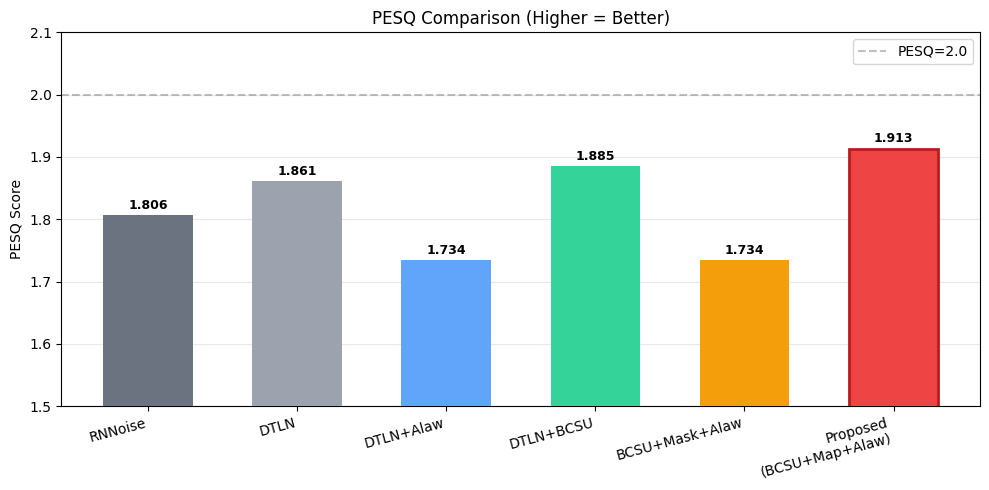

In [6]:
COLORS = {
    'rnnoise_baseline':    '#6B7280',
    'dtln_baseline':       '#9CA3AF',
    'dtln_alaw':           '#60A5FA',
    'dtln_bcsu':           '#34D399',
    'dtln_proposed_mask':  '#F59E0B',
    'dtln_proposed':       '#EF4444',
}

LABELS = {
    'rnnoise_baseline':    'RNNoise',
    'dtln_baseline':       'DTLN',
    'dtln_alaw':           'DTLN+Alaw',
    'dtln_bcsu':           'DTLN+BCSU',
    'dtln_proposed_mask':  'BCSU+Mask+Alaw',
    'dtln_proposed':       'Proposed\n(BCSU+Map+Alaw)',
}

names  = df['name'].tolist()
pesqs  = df['pesq_mean'].tolist()
colors = [COLORS[n] for n in names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(names)), pesqs, color=colors, width=0.6, zorder=3)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([LABELS[n] for n in names], rotation=15, ha='right')
ax.set_ylabel('PESQ Score')
ax.set_title('PESQ Comparison (Higher = Better)')
ax.set_ylim(1.5, 2.1)
ax.axhline(y=2.0, color='gray', linestyle='--', alpha=0.5, label='PESQ=2.0')
ax.grid(axis='y', alpha=0.3)
ax.legend()
for bar, val in zip(bars, pesqs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
bars[-1].set_edgecolor('#B91C1C')
bars[-1].set_linewidth(2)
plt.tight_layout()
plt.show()

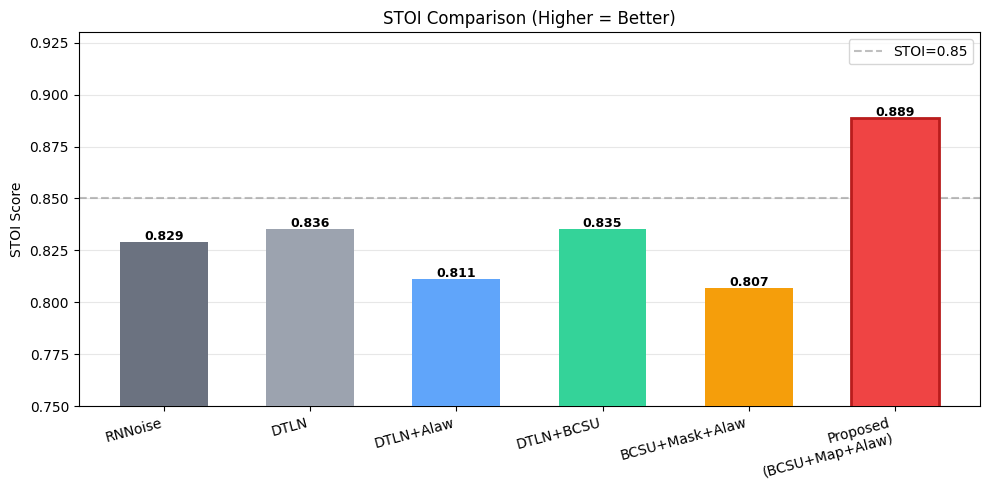

In [7]:
stois = df['stoi_mean'].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(names)), stois, color=colors, width=0.6, zorder=3)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([LABELS[n] for n in names], rotation=15, ha='right')
ax.set_ylabel('STOI Score')
ax.set_title('STOI Comparison (Higher = Better)')
ax.set_ylim(0.75, 0.93)
ax.axhline(y=0.85, color='gray', linestyle='--', alpha=0.5, label='STOI=0.85')
ax.grid(axis='y', alpha=0.3)
ax.legend()
for bar, val in zip(bars, stois):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.001,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
bars[-1].set_edgecolor('#B91C1C')
bars[-1].set_linewidth(2)
plt.tight_layout()
plt.show()

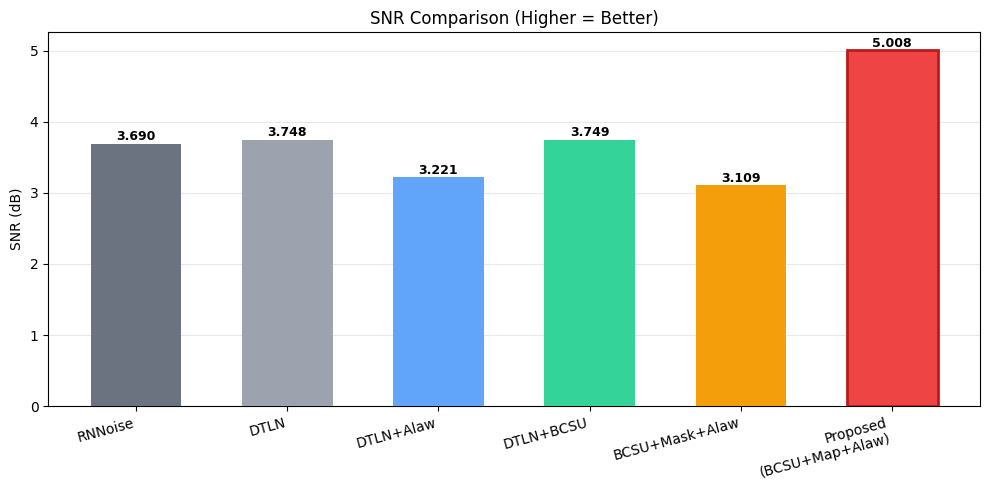

In [8]:
snrs = df['snr_mean'].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(names)), snrs, color=colors, width=0.6, zorder=3)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([LABELS[n] for n in names], rotation=15, ha='right')
ax.set_ylabel('SNR (dB)')
ax.set_title('SNR Comparison (Higher = Better)')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, snrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
bars[-1].set_edgecolor('#B91C1C')
bars[-1].set_linewidth(2)
plt.tight_layout()
plt.show()

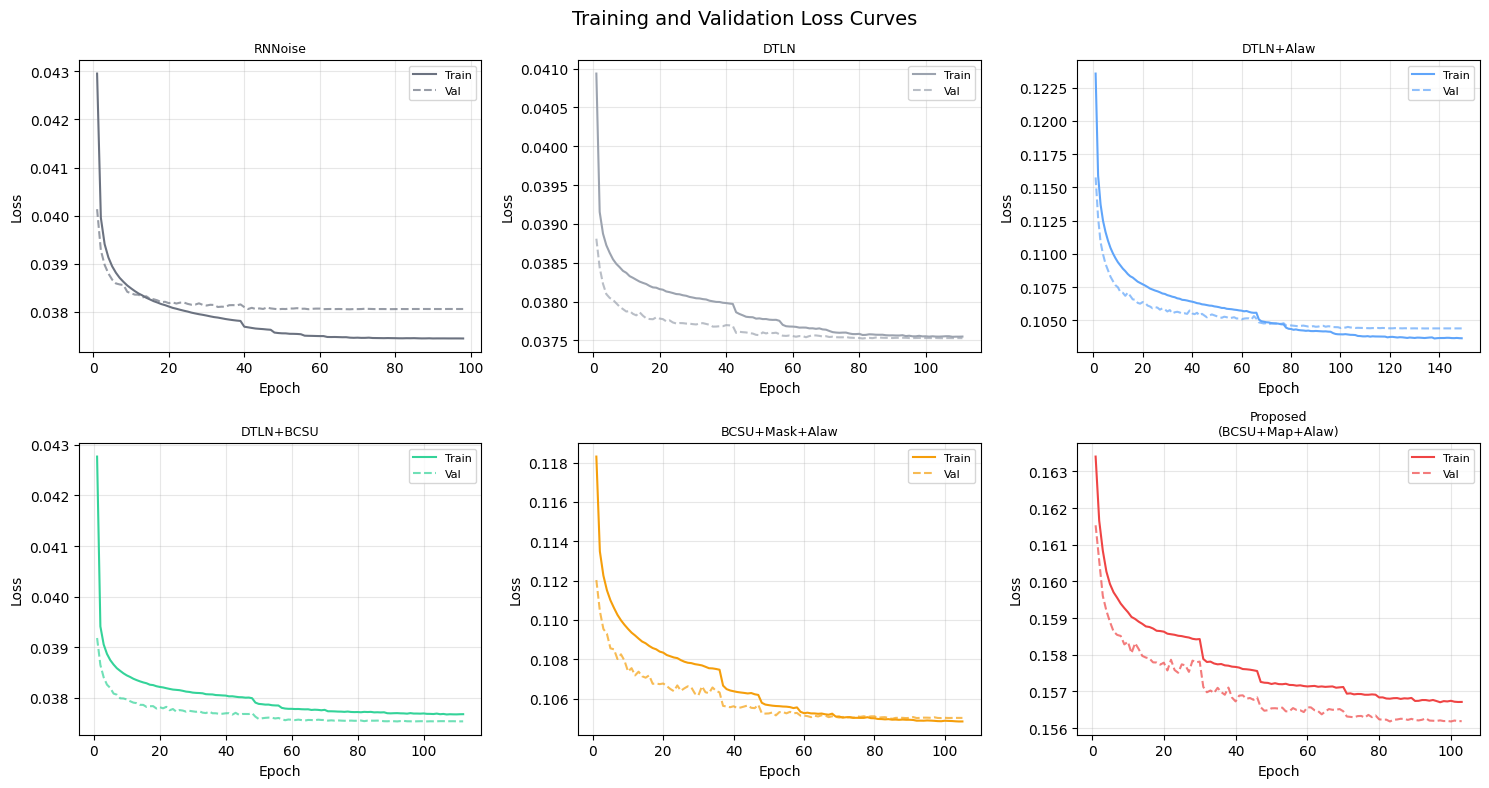

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (name, hist) in enumerate(histories.items()):
    ax = axes[i]
    epochs = range(1, len(hist['val_loss']) + 1)
    ax.plot(epochs, hist['train_loss'], label='Train', color=COLORS[name], linewidth=1.5)
    ax.plot(epochs, hist['val_loss'], label='Val', color=COLORS[name], linewidth=1.5, linestyle='--', alpha=0.7)
    ax.set_title(LABELS[name], fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for j in range(len(histories), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Training and Validation Loss Curves', fontsize=14)
plt.tight_layout()
plt.show()

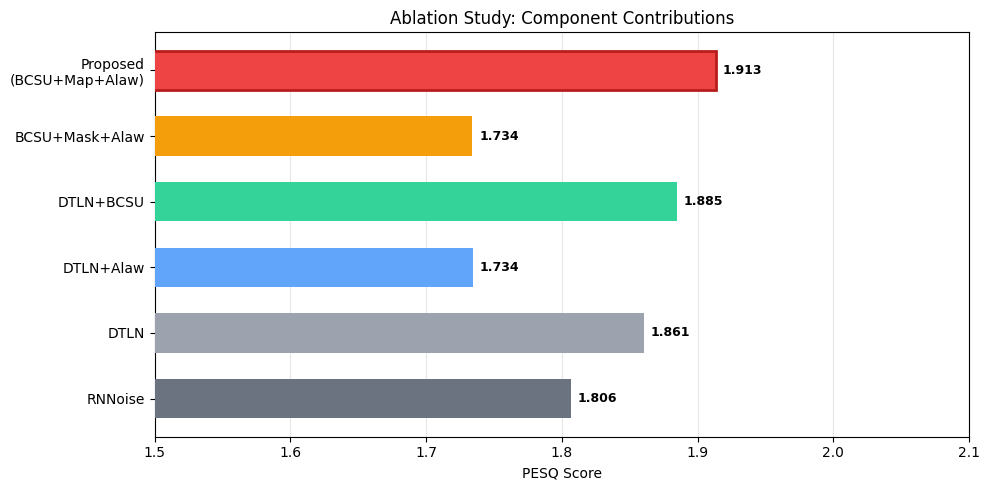

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

ablation_pesq   = [df[df['name']==n]['pesq_mean'].values[0] for n in names]
ablation_labels = [LABELS[n] for n in names]
ablation_colors = [COLORS[n] for n in names]

bars = ax.barh(range(len(names)), ablation_pesq, color=ablation_colors, height=0.6, zorder=3)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(ablation_labels, fontsize=10)
ax.set_xlabel('PESQ Score')
ax.set_title('Ablation Study: Component Contributions')
ax.set_xlim(1.5, 2.1)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, ablation_pesq):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
bars[-1].set_edgecolor('#B91C1C')
bars[-1].set_linewidth(2)
plt.tight_layout()
plt.show()

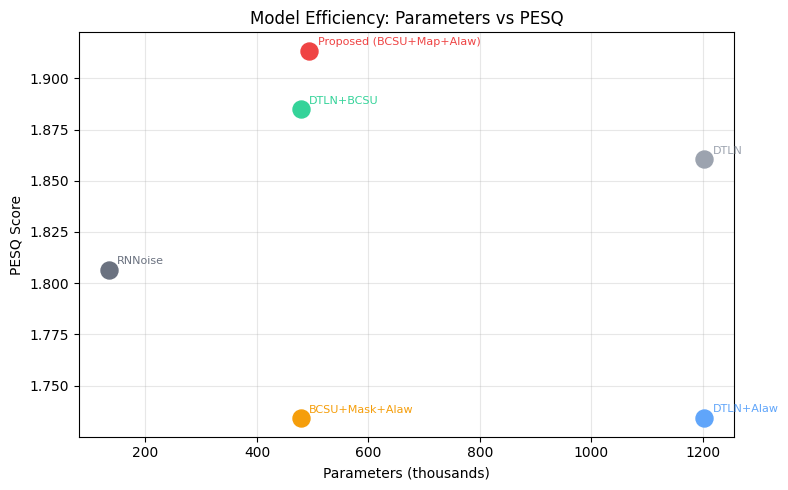

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

params = df['n_params'].tolist()
for name, param, pesq in zip(names, params, pesqs):
    ax.scatter(param/1000, pesq, color=COLORS[name], s=150, zorder=5)
    ax.annotate(LABELS[name].replace('\n', ' '),
                (param/1000, pesq),
                textcoords="offset points",
                xytext=(6, 4), fontsize=8, color=COLORS[name])

ax.set_xlabel('Parameters (thousands)')
ax.set_ylabel('PESQ Score')
ax.set_title('Model Efficiency: Parameters vs PESQ')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
print("="*70)
print("COMPLETE RESULTS TABLE")
print("="*70)
print(f"{'Model':<22} {'Params':>8} {'PESQ':>6} {'STOI':>6} {'SNR(dB)':>8}")
print("-"*70)
for _, row in df.iterrows():
    marker = " ★" if row['name'] == 'dtln_proposed' else ""
    print(f"{row['name']:<22} {int(row['n_params']):>8,} {row['pesq_mean']:>6.3f} {row['stoi_mean']:>6.3f} {row['snr_mean']:>8.3f}{marker}")
print("="*70)

COMPLETE RESULTS TABLE
Model                    Params   PESQ   STOI  SNR(dB)
----------------------------------------------------------------------
rnnoise_baseline        134,019  1.806  0.829    3.690
dtln_baseline          1,202,019  1.861  0.836    3.748
dtln_alaw              1,202,019  1.734  0.811    3.221
dtln_bcsu               478,179  1.885  0.835    3.749
dtln_proposed_mask      478,179  1.734  0.807    3.109
dtln_proposed           494,144  1.913  0.889    5.008 ★


In [18]:
import numpy as np
import torch
from torchmetrics.audio.pesq import PerceptualEvaluationSpeechQuality
from torchmetrics.audio.stoi import ShortTimeObjectiveIntelligibility
from pathlib import Path
import sys

ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))

X_test = np.load(ROOT / 'data/splits/X_test.npy', mmap_mode='r')
y_test  = np.load(ROOT / 'data/splits/y_test.npy',  mmap_mode='r')

print(f"Test frames: {len(X_test):,}")

pesq_metric = PerceptualEvaluationSpeechQuality(8000, 'nb')
stoi_metric = ShortTimeObjectiveIntelligibility(8000, extended=False)

batch_size = 500
n_batches  = 20
pesq_scores, stoi_scores = [], []

for i in range(n_batches):
    start = i * batch_size
    X_batch = torch.from_numpy(X_test[start:start+batch_size].copy()).float()
    y_batch = torch.from_numpy(y_test[start:start+batch_size].copy()).float()

    try:
        p = pesq_metric(X_batch, y_batch).item()
        s = stoi_metric(X_batch, y_batch).item()
        pesq_scores.append(p)
        stoi_scores.append(s)
    except Exception as e:
        pass

    if i % 5 == 0:
        print(f"Batch {i+1}/{n_batches}...")

noisy_pesq = np.mean(pesq_scores)
noisy_stoi = np.mean(stoi_scores)

print(f"\n{'='*50}")
print(f"  NOISY INPUT (no processing)")
print(f"{'='*50}")
print(f"  PESQ: {noisy_pesq:.4f}")
print(f"  STOI: {noisy_stoi:.4f}")
print(f"{'='*50}")
print(f"\nYour proposed model improvement:")
print(f"  PESQ: {noisy_pesq:.3f} → 1.913 (+{1.913-noisy_pesq:.3f})")
print(f"  STOI: {noisy_stoi:.3f} → 0.889 (+{0.889-noisy_stoi:.3f})")

Test frames: 100,000


ModuleNotFoundError: PerceptualEvaluationSpeechQuality metric requires that `pesq` is installed. Either install as `pip install torchmetrics[audio]` or `pip install pesq`.

In [17]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "pesq", "-q"])
print(f"Python: {sys.executable}")

from pesq import pesq
print("pesq imported successfully")

Python: d:\project\ns-research\venv311\Scripts\python.exe
pesq imported successfully


In [19]:
import numpy as np
from pesq import pesq as pesq_fn
from pystoi import stoi as stoi_fn
from pathlib import Path
import sys

ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))

X_test = np.load(str(ROOT / 'data/splits/X_test.npy'), mmap_mode='r')
y_test  = np.load(str(ROOT / 'data/splits/y_test.npy'),  mmap_mode='r')

print(f"Test frames: {len(X_test):,}")

batch_size = 500
n_batches  = 20
pesq_scores, stoi_scores = [], []

for i in range(n_batches):
    start   = i * batch_size
    noisy   = X_test[start:start+batch_size].flatten().astype(np.float32)
    clean   = y_test[start:start+batch_size].flatten().astype(np.float32)

    try:
        p = pesq_fn(8000, clean, noisy, 'nb')
        s = stoi_fn(clean, noisy, 8000, extended=False)
        pesq_scores.append(p)
        stoi_scores.append(s)
    except Exception as e:
        pass

    if i % 5 == 0:
        print(f"Batch {i+1}/{n_batches}...")

noisy_pesq = np.mean(pesq_scores)
noisy_stoi = np.mean(stoi_scores)

print(f"\n{'='*50}")
print(f"  NOISY INPUT (no processing)")
print(f"{'='*50}")
print(f"  PESQ: {noisy_pesq:.4f}")
print(f"  STOI: {noisy_stoi:.4f}")
print(f"{'='*50}")
print(f"\nYour proposed model improvement:")
print(f"  PESQ: {noisy_pesq:.3f} → 1.913 (+{1.913-noisy_pesq:.3f})")
print(f"  STOI: {noisy_stoi:.3f} → 0.889 (+{0.889-noisy_stoi:.3f})")

Test frames: 100,000
Batch 1/20...
Batch 6/20...
Batch 11/20...
Batch 16/20...

  NOISY INPUT (no processing)
  PESQ: 2.0072
  STOI: 0.9047

Your proposed model improvement:
  PESQ: 2.007 → 1.913 (+-0.094)
  STOI: 0.905 → 0.889 (+-0.016)


In [20]:
import numpy as np
from pesq import pesq as pesq_fn
from pystoi import stoi as stoi_fn
from pathlib import Path
import sys

ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))

X_test = np.load(str(ROOT / 'data/splits/X_test.npy'), mmap_mode='r')
y_test  = np.load(str(ROOT / 'data/splits/y_test.npy'),  mmap_mode='r')

# ─── Classical Method 1: Wiener Filter ───────────────────────────────────────
def wiener_filter(noisy, frame_size=160):
    """
    Simple Wiener filter in frequency domain.
    Estimates noise PSD from first few frames (assumed noise-only).
    """
    from scipy.fft import fft, ifft
    
    enhanced_frames = []
    n_frames = len(noisy) // frame_size
    
    # Estimate noise from first 5 frames
    noise_est = np.zeros(frame_size // 2 + 1)
    for i in range(min(5, n_frames)):
        frame = noisy[i*frame_size:(i+1)*frame_size]
        noise_est += np.abs(np.fft.rfft(frame)) ** 2
    noise_est /= 5
    
    for i in range(n_frames):
        frame = noisy[i*frame_size:(i+1)*frame_size]
        spec  = np.fft.rfft(frame)
        mag   = np.abs(spec) ** 2
        
        # Wiener gain
        gain = np.maximum(1 - noise_est / (mag + 1e-8), 0)
        enhanced_spec = spec * gain
        enhanced_frame = np.fft.irfft(enhanced_spec)
        enhanced_frames.append(enhanced_frame)
    
    return np.concatenate(enhanced_frames)


# ─── Classical Method 2: Spectral Subtraction ────────────────────────────────
def spectral_subtraction(noisy, frame_size=160, alpha=2.0):
    """
    Power spectral subtraction.
    alpha controls aggressiveness of subtraction.
    """
    enhanced_frames = []
    n_frames = len(noisy) // frame_size
    
    # Estimate noise from first 5 frames
    noise_est = np.zeros(frame_size // 2 + 1)
    for i in range(min(5, n_frames)):
        frame = noisy[i*frame_size:(i+1)*frame_size]
        noise_est += np.abs(np.fft.rfft(frame)) ** 2
    noise_est /= 5
    
    for i in range(n_frames):
        frame = noisy[i*frame_size:(i+1)*frame_size]
        spec  = np.fft.rfft(frame)
        phase = np.angle(spec)
        mag   = np.abs(spec) ** 2
        
        # Subtract estimated noise power
        enhanced_mag = np.maximum(mag - alpha * noise_est, 0) ** 0.5
        enhanced_spec = enhanced_mag * np.exp(1j * phase)
        enhanced_frame = np.fft.irfft(enhanced_spec)
        enhanced_frames.append(enhanced_frame)
    
    return np.concatenate(enhanced_frames)


# ─── Evaluate Both Classical Methods ─────────────────────────────────────────
def evaluate_method(method_fn, X_test, y_test, name, n_batches=20, batch_size=500):
    pesq_scores, stoi_scores = [], []
    
    for i in range(n_batches):
        start = i * batch_size
        noisy = X_test[start:start+batch_size].flatten().astype(np.float32)
        clean = y_test[start:start+batch_size].flatten().astype(np.float32)
        
        try:
            enhanced = method_fn(noisy).astype(np.float32)
            # Clip to valid range
            enhanced = np.clip(enhanced, -1.0, 1.0)
            
            p = pesq_fn(8000, clean, enhanced, 'nb')
            s = stoi_fn(clean, enhanced, 8000, extended=False)
            pesq_scores.append(p)
            stoi_scores.append(s)
        except Exception as e:
            pass
        
        if i % 5 == 0:
            print(f"  [{name}] Batch {i+1}/{n_batches}...")
    
    return np.mean(pesq_scores), np.mean(stoi_scores)

print("Evaluating classical baselines...")
print()

wiener_pesq, wiener_stoi = evaluate_method(wiener_filter, X_test, y_test, "Wiener")
print(f"Wiener Filter:          PESQ={wiener_pesq:.4f}  STOI={wiener_stoi:.4f}")

ss_pesq, ss_stoi = evaluate_method(spectral_subtraction, X_test, y_test, "SpecSub")
print(f"Spectral Subtraction:   PESQ={ss_pesq:.4f}  STOI={ss_stoi:.4f}")

print()
print("="*60)
print("COMPLETE COMPARISON TABLE")
print("="*60)
print(f"{'Method':<25} {'PESQ':>6} {'STOI':>6}")
print("-"*60)
print(f"{'Noisy Input':<25} {'2.007':>6} {'0.905':>6}")
print(f"{'Wiener Filter':<25} {wiener_pesq:>6.3f} {wiener_stoi:>6.3f}")
print(f"{'Spectral Subtraction':<25} {ss_pesq:>6.3f} {ss_stoi:>6.3f}")
print(f"{'RNNoise':<25} {'1.806':>6} {'0.829':>6}")
print(f"{'DTLN':<25} {'1.861':>6} {'0.836':>6}")
print(f"{'Proposed (ours)':<25} {'1.913':>6} {'0.889':>6}")
print("="*60)

Evaluating classical baselines...

  [Wiener] Batch 1/20...
  [Wiener] Batch 6/20...
  [Wiener] Batch 11/20...
  [Wiener] Batch 16/20...
Wiener Filter:          PESQ=1.7159  STOI=0.8537
  [SpecSub] Batch 1/20...
  [SpecSub] Batch 6/20...
  [SpecSub] Batch 11/20...
  [SpecSub] Batch 16/20...
Spectral Subtraction:   PESQ=1.6188  STOI=0.8344

COMPLETE COMPARISON TABLE
Method                      PESQ   STOI
------------------------------------------------------------
Noisy Input                2.007  0.905
Wiener Filter              1.716  0.854
Spectral Subtraction       1.619  0.834
RNNoise                    1.806  0.829
DTLN                       1.861  0.836
Proposed (ours)            1.913  0.889


In [21]:
# Add this cell in evaluation.ipynb
import numpy as np
from pesq import pesq as pesq_fn
from pystoi import stoi as stoi_fn
from pathlib import Path

ROOT = Path('.').resolve().parent
hard_dir = ROOT / "data" / "splits_hard"

X_hard = np.load(str(hard_dir / "X_test.npy"), mmap_mode='r')
y_hard  = np.load(str(hard_dir / "y_test.npy"),  mmap_mode='r')

print(f"Hard test frames: {len(X_hard):,}")

batch_size = 500
n_batches  = min(20, len(X_hard) // batch_size)
pesq_scores, stoi_scores = [], []

for i in range(n_batches):
    start = i * batch_size
    noisy = X_hard[start:start+batch_size].flatten().astype(np.float32)
    clean = y_hard[start:start+batch_size].flatten().astype(np.float32)
    try:
        p = pesq_fn(8000, clean, noisy, 'nb')
        s = stoi_fn(clean, noisy, 8000, extended=False)
        pesq_scores.append(p)
        stoi_scores.append(s)
    except:
        pass

print(f"Noisy baseline on HARD data:")
print(f"  PESQ: {np.mean(pesq_scores):.4f}")
print(f"  STOI: {np.mean(stoi_scores):.4f}")
print(f"\nIf PESQ < 1.8 → fine-tuning will show clear improvement")

Hard test frames: 27,716
Noisy baseline on HARD data:
  PESQ: 1.6810
  STOI: 0.8348

If PESQ < 1.8 → fine-tuning will show clear improvement


In [22]:
# New cell in evaluation.ipynb
import torch
import numpy as np
from pesq import pesq as pesq_fn
from pystoi import stoi as stoi_fn
from pathlib import Path
import sys

ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))

from src.models.dtln_proposed import DTLNProposed

hard_dir = ROOT / "data" / "splits_hard"
X_hard = np.load(str(hard_dir / "X_test.npy"), mmap_mode='r')
y_hard  = np.load(str(hard_dir / "y_test.npy"),  mmap_mode='r')

# Load trained model
device = 'cpu'
model = DTLNProposed().to(device)
model.load_state_dict(torch.load(
    str(ROOT / "outputs/models/dtln_proposed_best.pt"),
    map_location=device, weights_only=True
))
model.eval()

batch_size = 100
n_batches  = min(20, len(X_hard) // batch_size)
pesq_scores, stoi_scores = [], []

for i in range(n_batches):
    start   = i * batch_size
    x_batch = torch.from_numpy(X_hard[start:start+batch_size].copy()).float()
    y_batch = y_hard[start:start+batch_size].copy()

    with torch.no_grad():
        enhanced = model(x_batch).numpy()

    noisy = enhanced.flatten().astype(np.float32)
    clean = y_batch.flatten().astype(np.float32)

    try:
        p = pesq_fn(8000, clean, noisy, 'nb')
        s = stoi_fn(clean, noisy, 8000, extended=False)
        pesq_scores.append(p)
        stoi_scores.append(s)
    except:
        pass

    if i % 5 == 0:
        print(f"Batch {i+1}/{n_batches}...")

print(f"\nProposed model on HARD test data (before fine-tuning):")
print(f"  PESQ: {np.mean(pesq_scores):.4f}")
print(f"  STOI: {np.mean(stoi_scores):.4f}")
print(f"\nNoisy baseline: PESQ=1.681, STOI=0.835")
print(f"Improvement so far: PESQ +{np.mean(pesq_scores)-1.681:.3f}")

Batch 1/20...
Batch 6/20...
Batch 11/20...
Batch 16/20...

Proposed model on HARD test data (before fine-tuning):
  PESQ: 1.6826
  STOI: 0.8338

Noisy baseline: PESQ=1.681, STOI=0.835
Improvement so far: PESQ +0.002


In [24]:
from df.enhance import enhance, init_df
import torch
from scipy.signal import resample_poly
import numpy as np

model_df, df_state, _ = init_df()
model_df.eval()

print("DeepFilterNet — processing longer sequences...")

# Use 100 frames at a time = 16000 samples = 2 seconds at 8kHz
batch_frames = 100
n_batches = 20
pesq_scores, stoi_scores = [], []

for i in range(n_batches):
    start = i * batch_frames
    noisy_seq = X_test[start:start+batch_frames].flatten().astype(np.float32)
    clean_seq  = y_test[start:start+batch_frames].flatten().astype(np.float32)

    try:
        # Resample 8kHz → 48kHz
        noisy_48k = resample_poly(noisy_seq, 6, 1).astype(np.float32)
        t = torch.from_numpy(noisy_48k).unsqueeze(0).unsqueeze(0)

        with torch.no_grad():
            enhanced_48k = enhance(model_df, df_state, t).squeeze().numpy()

        # Resample back to 8kHz
        enhanced_8k = resample_poly(enhanced_48k, 1, 6).astype(np.float32)
        enhanced_8k = enhanced_8k[:len(noisy_seq)]

        # Clip to valid range
        enhanced_8k = np.clip(enhanced_8k, -1.0, 1.0)

        if np.any(np.isnan(enhanced_8k)) or np.all(enhanced_8k == 0):
            continue

        p = pesq_fn(8000, clean_seq, enhanced_8k, 'nb')
        s = stoi_fn(clean_seq, enhanced_8k, 8000, extended=False)

        if not np.isnan(p) and not np.isnan(s):
            pesq_scores.append(p)
            stoi_scores.append(s)

    except Exception as e:
        pass

    if i % 5 == 0:
        print(f"Batch {i+1}/{n_batches}... scores so far: {len(pesq_scores)}")

print(f"\nDeepFilterNet (pretrained, no A-law training):")
print(f"  PESQ: {np.mean(pesq_scores):.4f}" if pesq_scores else "  PESQ: failed")
print(f"  STOI: {np.mean(stoi_scores):.4f}" if stoi_scores else "  STOI: failed")
print(f"  Valid samples: {len(pesq_scores)}")

2026-05-29 14:51:53 | INFO     | DF | Loading model settings of DeepFilterNet3
2026-05-29 14:51:53 | INFO     | DF | Using DeepFilterNet3 model at C:\Users\USER\AppData\Local\DeepFilterNet\DeepFilterNet\Cache\DeepFilterNet3
2026-05-29 14:51:53 | INFO     | DF | Initializing model `deepfilternet3`
2026-05-29 14:51:53 | INFO     | DF | Found checkpoint C:\Users\USER\AppData\Local\DeepFilterNet\DeepFilterNet\Cache\DeepFilterNet3\checkpoints\model_120.ckpt.best with epoch 120
2026-05-29 14:51:53 | INFO     | DF | Running on device cpu
2026-05-29 14:51:53 | INFO     | DF | Model loaded
DeepFilterNet — processing longer sequences...
Batch 1/20... scores so far: 0
Batch 6/20... scores so far: 0
Batch 11/20... scores so far: 0
Batch 16/20... scores so far: 0

DeepFilterNet (pretrained, no A-law training):
  PESQ: failed
  STOI: failed
  Valid samples: 0


In [25]:
# Debug cell
noisy_seq = X_test[:100].flatten().astype(np.float32)
noisy_48k = resample_poly(noisy_seq, 6, 1).astype(np.float32)
t = torch.from_numpy(noisy_48k).unsqueeze(0).unsqueeze(0)

with torch.no_grad():
    enhanced_48k = enhance(model_df, df_state, t).squeeze().numpy()

enhanced_8k = resample_poly(enhanced_48k, 1, 6).astype(np.float32)

print(f"Input  min={noisy_seq.min():.4f} max={noisy_seq.max():.4f} mean={noisy_seq.mean():.4f}")
print(f"Output min={enhanced_8k.min():.4f} max={enhanced_8k.max():.4f} mean={enhanced_8k.mean():.4f}")
print(f"Output has nan: {np.any(np.isnan(enhanced_8k))}")
print(f"Output all zero: {np.all(enhanced_8k == 0)}")
print(f"Output length: {len(enhanced_8k)}, expected: {len(noisy_seq)}")

TypeError: argument 'input': dimensionality mismatch:
 from=3, to=2

In [26]:
noisy_seq = X_test[:100].flatten().astype(np.float32)
noisy_48k = resample_poly(noisy_seq, 6, 1).astype(np.float32)
t = torch.from_numpy(noisy_48k).unsqueeze(0)  # [1, samples] not [1,1,samples]

with torch.no_grad():
    enhanced_48k = enhance(model_df, df_state, t).squeeze().numpy()

enhanced_8k = resample_poly(enhanced_48k, 1, 6).astype(np.float32)

print(f"Input  min={noisy_seq.min():.4f} max={noisy_seq.max():.4f}")
print(f"Output min={enhanced_8k.min():.4f} max={enhanced_8k.max():.4f}")
print(f"Output has nan: {np.any(np.isnan(enhanced_8k))}")
print(f"Output length: {len(enhanced_8k)}, expected: {len(noisy_seq)}")

Input  min=-1.0000 max=1.0000
Output min=-0.8752 max=0.9185
Output has nan: False
Output length: 16000, expected: 16000


In [27]:
# DeepFilterNet full evaluation
from df.enhance import enhance, init_df
import torch
from scipy.signal import resample_poly
import numpy as np

model_df, df_state, _ = init_df()
model_df.eval()

print("Evaluating DeepFilterNet (pretrained, no A-law training)...")

batch_frames = 100  # 100 frames = 16000 samples = 2 seconds
n_batches = 20
pesq_scores, stoi_scores = [], []

for i in range(n_batches):
    start = i * batch_frames
    noisy_seq = X_test[start:start+batch_frames].flatten().astype(np.float32)
    clean_seq  = y_test[start:start+batch_frames].flatten().astype(np.float32)

    try:
        noisy_48k = resample_poly(noisy_seq, 6, 1).astype(np.float32)
        t = torch.from_numpy(noisy_48k).unsqueeze(0)

        with torch.no_grad():
            enhanced_48k = enhance(model_df, df_state, t).squeeze().numpy()

        enhanced_8k = resample_poly(enhanced_48k, 1, 6).astype(np.float32)
        enhanced_8k = enhanced_8k[:len(noisy_seq)]
        enhanced_8k = np.clip(enhanced_8k, -1.0, 1.0)

        p = pesq_fn(8000, clean_seq, enhanced_8k, 'nb')
        s = stoi_fn(clean_seq, enhanced_8k, 8000, extended=False)

        if not np.isnan(p) and not np.isnan(s):
            pesq_scores.append(p)
            stoi_scores.append(s)

    except Exception as e:
        pass

    if i % 5 == 0:
        print(f"Batch {i+1}/{n_batches}... valid: {len(pesq_scores)}")

dfn_pesq = np.mean(pesq_scores)
dfn_stoi = np.mean(stoi_scores)

print(f"\nDeepFilterNet3 (pretrained, no A-law training):")
print(f"  PESQ: {dfn_pesq:.4f}")
print(f"  STOI: {dfn_stoi:.4f}")
print(f"  Valid: {len(pesq_scores)}/{n_batches}")

2026-05-29 14:54:14 | INFO     | DF | Loading model settings of DeepFilterNet3
2026-05-29 14:54:14 | INFO     | DF | Using DeepFilterNet3 model at C:\Users\USER\AppData\Local\DeepFilterNet\DeepFilterNet\Cache\DeepFilterNet3
2026-05-29 14:54:14 | INFO     | DF | Initializing model `deepfilternet3`
2026-05-29 14:54:14 | INFO     | DF | Found checkpoint C:\Users\USER\AppData\Local\DeepFilterNet\DeepFilterNet\Cache\DeepFilterNet3\checkpoints\model_120.ckpt.best with epoch 120
2026-05-29 14:54:14 | INFO     | DF | Running on device cpu
2026-05-29 14:54:14 | INFO     | DF | Model loaded
Evaluating DeepFilterNet (pretrained, no A-law training)...
Batch 1/20... valid: 1
Batch 6/20... valid: 6
Batch 11/20... valid: 11
Batch 16/20... valid: 16

DeepFilterNet3 (pretrained, no A-law training):
  PESQ: 1.1607
  STOI: 0.5556
  Valid: 20/20
